In [1]:
import sys
import pandas as pd
import glob
import numpy as np
import os
import pickle
import scipy as scp
import seaborn as sns 
import matplotlib.pyplot as plt
import scipy.stats as stats

# make sure the working directory is the main repository!!!!
os.chdir("../../")
print(os.getcwd())

# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.size'] = 12
# plt.rcParams['axes.labelsize'] = 12
# plt.rcParams['axes.titlesize'] = 12
# plt.rcParams['xtick.labelsize'] = 12
# plt.rcParams['ytick.labelsize'] = 12
# plt.rcParams['legend.fontsize'] = 12
# plt.rcParams['figure.titlesize'] = 12

d:\github\modelling-active-sensing-collectives\GroupExperiment


In [2]:
# group_sizes
with open(r".\Data\AnalysisData\condensed_group_data.pickle", "rb") as f:
    store_scores = pickle.load(f)
    

In [3]:
raw_df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
raw_df= raw_df[raw_df["duration"]==30]
raw_df = raw_df[raw_df["consistency_type"]=="3/5"]

In [4]:
big_output_dir = "/media/adityamoger/T7 Shield/BACKUP_THESIS_DATA"
treatment_dir = big_output_dir + "/*_treatment"
null_dir = big_output_dir + "/*_null"
consistency_types = ["3/5", "2/3"]
experiment_types = ["positive_control", "negative_control", "treatment", "null"]
group_sizes = [5, 10, 30, 50, 75, 100]
iterations = np.arange(0, 20, 1)

store_individual_scores_labels = [
    (
        "experiment_type",
        "group_size",
        "iteration",
        "collision_counts",
        "wall_collision_counts",
        "bat_bat_collision_counts",
        "duration",
        "consistency_type",
        "bat_id",
    )
]

In [5]:
df = pd.DataFrame(store_scores[1:], columns= store_scores[0])
df= df[df["consistency_type"]=="3/5"]

df["collision_counts_scaled"] = df["collision_counts"]/(df["group_size"])
df["wall_collision_counts_scaled"] = df["wall_collision_counts"]/df["group_size"]
df["bat_bat_collision_counts_scaled"] = df["bat_bat_collision_counts"]/df["group_size"]

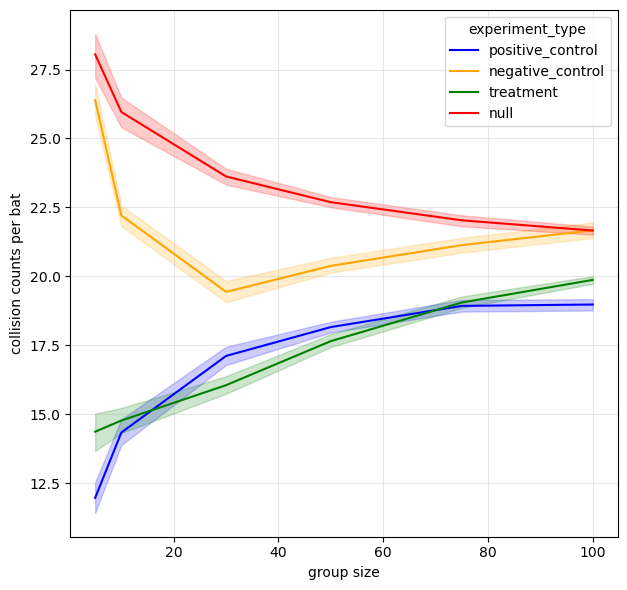

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="collision_counts_scaled", hue="experiment_type", palette = ["b", "orange", "g", "r"])
plt.ylabel('collision counts per bat')
plt.xlabel('group size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.rcParams['font.size'] = 15
# plt.style.use('dark_background')
plt.savefig(r".\Output\Results\collision_counts_vs_group_size.svg", transparent= True)
plt.show()
plt.clf()

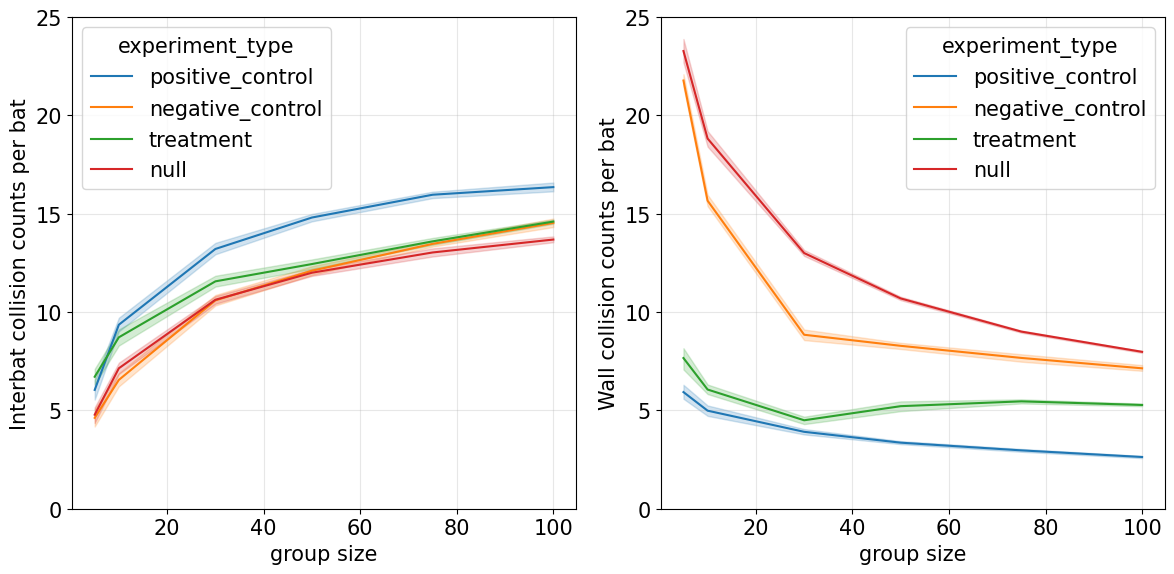

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="bat_bat_collision_counts_scaled", hue="experiment_type")
plt.ylim(0,25)
plt.ylabel('Interbat collision counts per bat')
plt.xlabel('group size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.subplot(1,2,2)
sns.lineplot(df[df["consistency_type"]=="3/5"], x="group_size", y="wall_collision_counts_scaled", hue="experiment_type")
plt.ylim(0,25)
plt.ylabel('Wall collision counts per bat')
plt.xlabel('group size')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r".\Output\Results\collision_counts_vs_group_size_breakdown.svg", transparent= True)
plt.show()
plt.clf()

In [8]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.genmod.families import NegativeBinomial
import pandas as pd
from patsy.contrasts import Treatment
# Convert all predictors to categorical (one-hot encoding)
# predictors = varying_params
varying_params = ["experiment_type", 'group_size']
labels = ['experiment type', 'group size']
df_cat = df.copy()

df_cat["group_size"] = pd.Categorical(df_cat["group_size"])
df_cat["experiment_type"] = pd.Categorical(df_cat["experiment_type"])

formula = """
collision_counts ~ C(experiment_type, Treatment(reference="positive_control")) + C(group_size, Treatment(reference=50))
"""

# First fit Poisson to estimate dispersion
poisson_model = smf.glm(formula=formula, data=df_cat, family=sm.families.Poisson()).fit()
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
print(dispersion)
alpha = 1/dispersion

# Fit Negative Binomial with categorical variables
model_nb = smf.glm(
    formula=formula,
    data=df_cat,
    family=NegativeBinomial(alpha=alpha),
    # contrasts=contrast_code
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)")
print(model_nb.summary2())
print(f"\nFinal alpha parameter: {model_nb.family.alpha:.4f}")

4.220940109196389
NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)
                                               Results: Generalized linear model
Model:                                     GLM                                   AIC:                                 6338.8009 
Link Function:                             Log                                   BIC:                                 -2875.7887
Dependent Variable:                        collision_counts                      Log-Likelihood:                      -3160.4   
Date:                                      2026-05-14 12:23                      LL-Null:                             -4112.3   
No. Observations:                          480                                   Deviance:                            32.065    
Df Model:                                  8                                     Pearson chi2:                        30.8      
Df Residuals:                              471                    

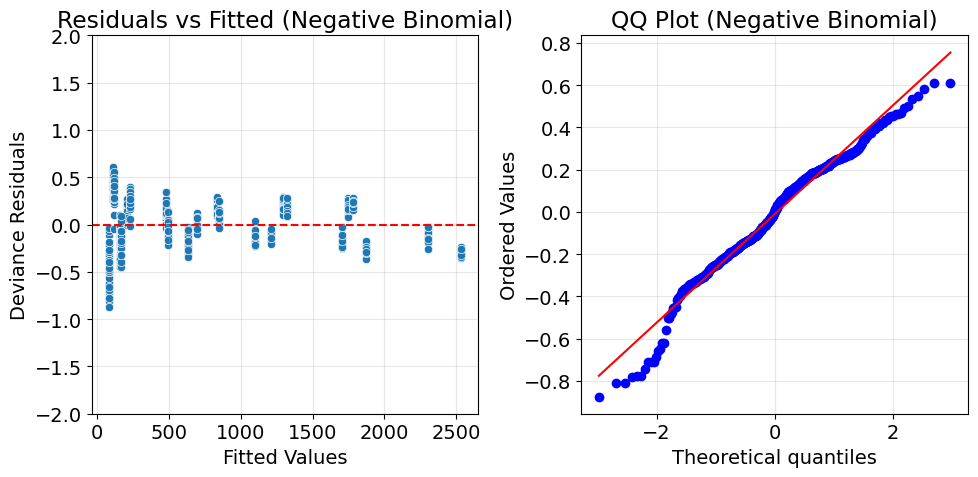

<Figure size 640x480 with 0 Axes>

In [9]:
plt.rcParams['font.size'] = 14
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
sns.scatterplot(x=model_nb.fittedvalues, y=model_nb.resid_deviance)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Negative Binomial)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-2,2)
# plt.tight_layout()
# plt.show()

# QQ Plot

plt.subplot(1,2,2)
stats.probplot(model_nb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Negative Binomial)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(r".\Output\Results\collision_counts_vs_group_size_glm_resid.svg", transparent= True)
plt.show()
plt.clf()

In [10]:
results = model_nb.summary2().tables[1]
categorical_params = [p for p in results.index if '[' in p]
print(categorical_params)
# Create a plot for each parameter
baseline_df = pd.DataFrame()
baseline_df["parameter"] = varying_params
baseline_df["odds_ratio"] = [1] * len(varying_params)
baseline_df["parameter_value"] = ['positive control', 50]
baseline_df["ci_low"] = [1] * len(varying_params)
baseline_df["ci_high"] = [1] * len(varying_params)
baseline_df["pvalue"] = [0] * len(varying_params)
baseline_df["coeffs"] = [0] * len(varying_params)

parameter_list = []
parameter_value_list = []
odds_ratio_list = []
ci_low_list = []
ci_high_list = []
pvalue_list = []
coeffs_list = []

for param in categorical_params:
    # Extract base parameter name and category
    base_param = param.split(',')[0].split(")")[0][2:]
    # base_param = param.split('[')[0]
    category = param.split('[')[1].split(']')[0].replace('T.', '')
    if category not in ["negative_control", "null", "treatment"]:
        category = float(category)
    # print(category)
    
    or_val = np.exp(results.loc[param, 'Coef.'])
    ci_low = np.exp(results.loc[param, '[0.025'])
    ci_high = np.exp(results.loc[param, '0.975]'])
    pvalue = results.loc[param, 'P>|z|']
    coeff= results.loc[param, 'Coef.']
    
    parameter_value_list.append(category)
    parameter_list.append(base_param)
    odds_ratio_list.append(or_val)
    ci_low_list.append(ci_low)
    ci_high_list.append(ci_high)
    pvalue_list.append(pvalue)
    coeffs_list.append(coeff)
    
new_df = pd.DataFrame()
new_df["parameter"] = parameter_list
new_df["odds_ratio"] = odds_ratio_list
new_df["parameter_value"] = parameter_value_list
new_df["ci_low"] = ci_low_list
new_df["ci_high"] = ci_high_list
new_df["pvalue"] = pvalue_list
new_df["coeffs"] = coeffs_list
condensed_nb_df = pd.concat((baseline_df,new_df)).reset_index()
condensed_nb_df.sort_values('parameter').to_csv("./Output/Results/group_nb_irr.csv")
print(condensed_nb_df)

['C(experiment_type, Treatment(reference="positive_control"))[T.negative_control]', 'C(experiment_type, Treatment(reference="positive_control"))[T.null]', 'C(experiment_type, Treatment(reference="positive_control"))[T.treatment]', 'C(group_size, Treatment(reference=50))[T.5]', 'C(group_size, Treatment(reference=50))[T.10]', 'C(group_size, Treatment(reference=50))[T.30]', 'C(group_size, Treatment(reference=50))[T.75]', 'C(group_size, Treatment(reference=50))[T.100]']
   index        parameter  odds_ratio   parameter_value    ci_low   ci_high  \
0      0  experiment_type    1.000000  positive control  1.000000  1.000000   
1      1       group_size    1.000000                50  1.000000  1.000000   
2      0  experiment_type    1.318647  negative_control  1.164839  1.492765   
3      1  experiment_type    1.450268              null  1.281150  1.641711   
4      2  experiment_type    1.021636         treatment  0.902376  1.156658   
5      3       group_size    0.098398               5.0

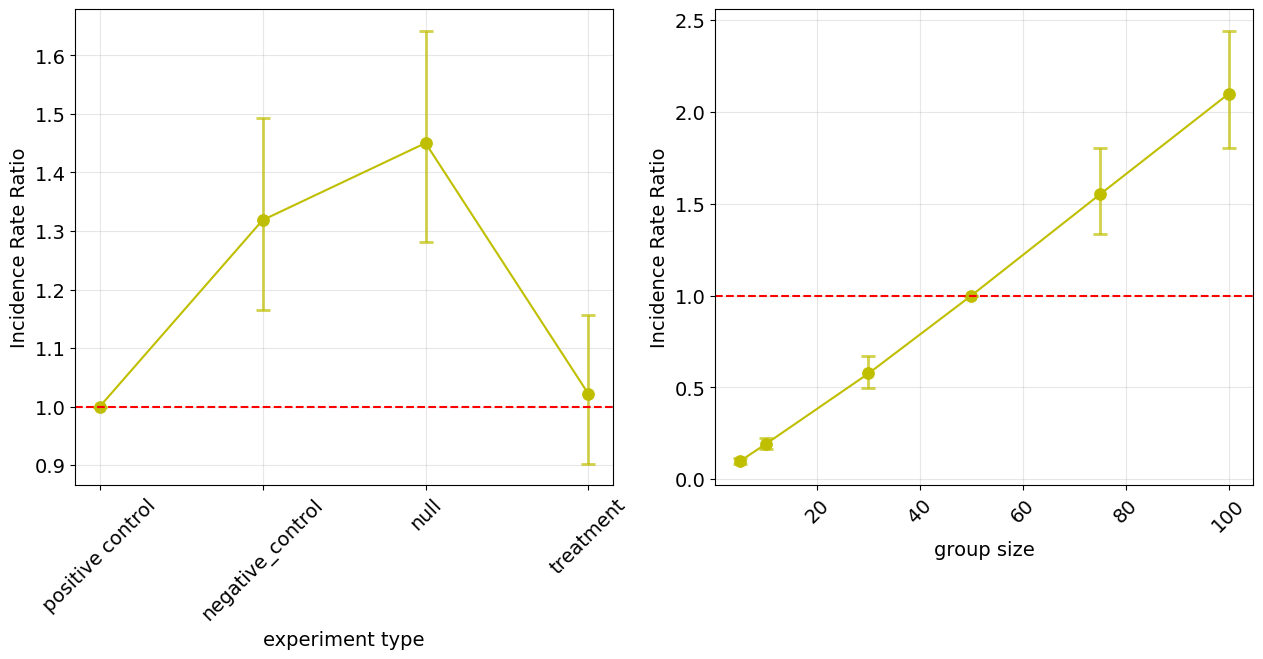

<Figure size 640x480 with 0 Axes>

In [11]:
plt.figure(figsize=(25, 25))
for i, param in enumerate(varying_params):
    subset_df = condensed_nb_df.groupby("parameter").get_group(param).reset_index()
    
    y_vals= subset_df['odds_ratio']
    x_vals= subset_df['parameter_value']
    lower = subset_df['ci_low']
    upper = subset_df['ci_high']
    lower_error = y_vals - lower
    upper_error = upper - y_vals
    # x_vals = [str(i) for i in x_vals]
    errors = [lower_error, upper_error]
    plt.subplot(4,4,i+3)
    ax = sns.lineplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], ls='-', color="y")  # Black line with dots
    sns.scatterplot(x=subset_df['parameter_value'], y=subset_df['odds_ratio'], s=100, color='y')
    
    plt.errorbar(x_vals, y_vals, yerr=errors,fmt='none',capsize=5,capthick=2, alpha=0.7,elinewidth=2, color="y"
    )
    plt.axhline(1, color='red', linestyle='--')
    plt.xlabel(labels[i])
    plt.ylabel('Incidence Rate Ratio')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.xticks(rotation=45)

plt.savefig(r".\Output\Results\collision_counts_vs_group_size_glm_irr.svg", transparent= True)
plt.show()
plt.clf()